# Analisis Data Penjualan — Associate Data Analyst
**Studi Kasus:** Menyediakan insight berbasis data dari penjualan (total penjualan per produk, wilayah, dan bulan).

Notebook ini mencakup:
1. Data Understanding (struktur, tipe data, kualitas data)
2. Data Cleaning (missing value, duplikasi, format tanggal tidak konsisten)
3. Feature Engineering (kolom bulan, tahun, nama bulan)
4. Analisis & Ringkasan (5 produk terlaris, ringkasan wilayah, tren bulanan, case tambahan)
5. Visualisasi (dashboard 3–5 chart)
6. Kesimpulan Insight & Rekomendasi


## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df_raw = pd.read_csv("data/dataset_penjualan_kotor.csv")
print("Jumlah baris:", df_raw.shape[0])
print("Jumlah kolom:", df_raw.shape[1])
df_raw.head()


Jumlah baris: 205
Jumlah kolom: 9


,transaction_id,product_id,product_name,region_id,region_name,date,quantity,price_per_unit,total_price
0,T9935,P001,Blender,R01,Jakarta,2024-06-22,3.0,456787,1370361.0
1,T4257,P001,Blender,R05,Makassar,2024-05-09,NaN,233326,933304.0
2,T3615,P005,Electric Kettle,R04,Medan,2024-01-02,2.0,671029,1342058.0
3,T2584,P004,Air Purifier,R03,Surabaya,27-01-2024,3.0,363032,1089096.0
4,T7201,P003,Vacuum Cleaner,R03,Surabaya,2024-05-17,5.0,477370,2386850.0


## 2. Data Understanding
Menelaah struktur data: jumlah kolom, tipe data, dan kesesuaian antar data — sebelum menentukan
apakah data ini layak dipakai untuk pengambilan keputusan.

In [2]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  205 non-null    str    
 1   product_id      205 non-null    str    
 2   product_name    205 non-null    str    
 3   region_id       205 non-null    str    
 4   region_name     205 non-null    str    
 5   date            205 non-null    str    
 6   quantity        195 non-null    float64
 7   price_per_unit  205 non-null    int64  
 8   total_price     197 non-null    float64
dtypes: float64(2), int64(1), str(6)
memory usage: 14.5 KB


In [3]:
print("Statistik deskriptif kolom numerik:")
df_raw.describe(include='all').T


Statistik deskriptif kolom numerik:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,205,197,T4258,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,205,5,P005,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,205,5,Electric Kettle,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_id,205,5,R03,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_name,205,5,Surabaya,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,205,145,2024-03-25,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,195.0,NaN,NaN,NaN,3.092308,1.308849,1.0,2.0,3.0,4.0,5.0
price_per_unit,205.0,NaN,NaN,NaN,563592.804878,223808.484775,206182.0,366889.0,544519.0,732060.0,999649.0
total_price,197.0,NaN,NaN,NaN,1717048.42132,1024510.981473,209767.0,962120.0,1420010.0,2356976.0,4733730.0


In [4]:
print("Jumlah missing value per kolom:")
print(df_raw.isna().sum())

print("\nJumlah baris duplikat penuh (semua kolom sama):", df_raw.duplicated().sum())
print("Jumlah transaction_id yang muncul lebih dari sekali:", df_raw['transaction_id'].duplicated().sum())

print("\nContoh variasi format tanggal (menunjukkan data belum konsisten):")
print(df_raw['date'].sample(10, random_state=1).tolist())


Jumlah missing value per kolom:
transaction_id     0
product_id         0
product_name       0
region_id          0
region_name        0
date               0
quantity          10
price_per_unit     0
total_price        8
dtype: int64

Jumlah baris duplikat penuh (semua kolom sama): 5
Jumlah transaction_id yang muncul lebih dari sekali: 8

Contoh variasi format tanggal (menunjukkan data belum konsisten):
['2024-06-26', '20-05-2024', '2024-04-11', '2024-03-25', '2024-03-19', '2024-01-11', '2024-05-11', '2024-05-20', '2024-03-15', '2024-04-09']


**Catatan kualitas data (temuan awal):**
- Ada baris yang **duplikat penuh** (transaksi tercatat dua kali).
- Ada `transaction_id` yang sama tetapi datanya **berbeda** (kemungkinan human error saat input ID).
- Kolom `quantity` dan `total_price` memiliki **missing value**.
- Kolom `date` memiliki **dua format berbeda** (`YYYY-MM-DD` dan `DD-MM-YYYY`) sehingga tidak bisa langsung diparse.
- Namun secara struktur (jumlah kolom & tipe data konsisten: id transaksi, id & nama produk, id & nama wilayah, tanggal, quantity, harga satuan, total harga), data ini **layak digunakan** setelah proses pembersihan karena relasi `total_price = quantity x price_per_unit` konsisten pada baris yang lengkap.

## 3. Data Cleaning

### 3.1 Hapus duplikasi penuh

In [5]:
df = df_raw.copy()
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Baris dihapus karena duplikat penuh: {before - after}")
print("Sisa baris:", df.shape[0])


Baris dihapus karena duplikat penuh: 5
Sisa baris: 200


### 3.2 Perbaiki format tanggal
Dataset punya dua format tanggal: `YYYY-MM-DD` dan `DD-MM-YYYY`. Kita deteksi otomatis lalu
seragamkan menjadi tipe `datetime`.

In [6]:
def parse_mixed_date(x):
    x = str(x).strip()
    for fmt in ("%Y-%m-%d", "%d-%m-%Y"):
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df['date'] = df['date'].apply(parse_mixed_date)
print("Jumlah tanggal gagal diparse:", df['date'].isna().sum())
df[['transaction_id', 'date']].head()


Jumlah tanggal gagal diparse: 0


,transaction_id,date
0,T9935,2024-06-22
1,T4257,2024-05-09
2,T3615,2024-01-02
3,T2584,2024-01-27
4,T7201,2024-05-17


### 3.3 Tangani missing value pada `quantity` dan `total_price`
Karena `total_price = quantity x price_per_unit` konsisten di seluruh baris yang lengkap, kita
bisa saling melengkapi nilai yang hilang:
- Jika `quantity` kosong tapi `total_price` ada → hitung `quantity = total_price / price_per_unit`
- Jika `total_price` kosong tapi `quantity` ada → hitung `total_price = quantity x price_per_unit`
- Jika keduanya kosong → baris dibuang (tidak bisa direkonstruksi)

In [7]:
mask_qty_missing = df['quantity'].isna() & df['total_price'].notna()
df.loc[mask_qty_missing, 'quantity'] = (df.loc[mask_qty_missing, 'total_price'] / df.loc[mask_qty_missing, 'price_per_unit']).round()

mask_total_missing = df['total_price'].isna() & df['quantity'].notna()
df.loc[mask_total_missing, 'total_price'] = df.loc[mask_total_missing, 'quantity'] * df.loc[mask_total_missing, 'price_per_unit']

before = df.shape[0]
df = df.dropna(subset=['quantity', 'total_price', 'date'])
after = df.shape[0]
print(f"Baris dibuang karena tidak bisa direkonstruksi (quantity & total_price kosong / tanggal invalid): {before - after}")

df['quantity'] = df['quantity'].astype(int)
print("Sisa missing value:\n", df.isna().sum())


Baris dibuang karena tidak bisa direkonstruksi (quantity & total_price kosong / tanggal invalid): 1
Sisa missing value:
 transaction_id    0
product_id        0
product_name      0
region_id         0
region_name       0
date              0
quantity          0
price_per_unit    0
total_price       0
dtype: int64


### 3.4 Validasi ulang `transaction_id` duplikat
`transaction_id` yang sama dengan data berbeda kemungkinan adalah error input ID (bukan transaksi
ganda), sehingga baris tetap dipertahankan sebagai transaksi terpisah, namun kita beri `row_id`
unik agar tidak ambigu dalam analisis lanjutan.

In [8]:
dup_id_count = df['transaction_id'].duplicated(keep=False).sum()
print("Baris dengan transaction_id yang masih bentrok setelah cleaning:", dup_id_count)

df = df.reset_index(drop=True)
df.insert(0, 'row_id', df.index + 1)
df.head()


Baris dengan transaction_id yang masih bentrok setelah cleaning: 6


,row_id,transaction_id,product_id,product_name,region_id,region_name,date,quantity,price_per_unit,total_price
0,1,T9935,P001,Blender,R01,Jakarta,2024-06-22,3,456787,1370361.0
1,2,T4257,P001,Blender,R05,Makassar,2024-05-09,4,233326,933304.0
2,3,T3615,P005,Electric Kettle,R04,Medan,2024-01-02,2,671029,1342058.0
3,4,T2584,P004,Air Purifier,R03,Surabaya,2024-01-27,3,363032,1089096.0
4,5,T7201,P003,Vacuum Cleaner,R03,Surabaya,2024-05-17,5,477370,2386850.0


## 4. Feature Engineering

In [9]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')
df['year_month'] = df['date'].dt.to_period('M').astype(str)

df.to_csv('output/dataset_penjualan_bersih.csv', index=False)
print("Data bersih disimpan ke output/dataset_penjualan_bersih.csv")
df.head()


Data bersih disimpan ke output/dataset_penjualan_bersih.csv


,row_id,transaction_id,product_id,product_name,region_id,region_name,date,quantity,price_per_unit,total_price,year,month,month_name,year_month
0,1,T9935,P001,Blender,R01,Jakarta,2024-06-22,3,456787,1370361.0,2024,6,Jun,2024-06
1,2,T4257,P001,Blender,R05,Makassar,2024-05-09,4,233326,933304.0,2024,5,May,2024-05
2,3,T3615,P005,Electric Kettle,R04,Medan,2024-01-02,2,671029,1342058.0,2024,1,Jan,2024-01
3,4,T2584,P004,Air Purifier,R03,Surabaya,2024-01-27,3,363032,1089096.0,2024,1,Jan,2024-01
4,5,T7201,P003,Vacuum Cleaner,R03,Surabaya,2024-05-17,5,477370,2386850.0,2024,5,May,2024-05


## 5. Identifikasi Variabel & Relevansi Analitik

| Kategori | Variabel | Relevansi |
|---|---|---|
| Waktu transaksi | `date`, `year`, `month`, `year_month` | Analisis tren penjualan per bulan/tahun |
| Kategori produk | `product_id`, `product_name` | Analisis performa & ranking produk |
| Wilayah | `region_id`, `region_name` | Analisis permintaan per wilayah |
| Nilai transaksi | `quantity`, `price_per_unit`, `total_price` | Ukuran volume & nilai penjualan |

Catatan: dataset ini **tidak memiliki kolom rating pelanggan** — hanya transaksi penjualan. Jika
tersedia di sumber data lain, kolom rating bisa ditambahkan untuk analisis kepuasan pelanggan.

## 6. Analisis & Ringkasan Informasi

### 6.1 Lima produk dengan penjualan tertinggi (berdasarkan total revenue)

In [10]:
top5_produk = (df.groupby('product_name')['total_price']
               .sum()
               .sort_values(ascending=False)
               .head(5)
               .reset_index()
               .rename(columns={'total_price': 'total_revenue'}))
top5_produk['total_revenue_fmt'] = top5_produk['total_revenue'].map(lambda x: f"Rp {x:,.0f}")
top5_produk


,product_name,total_revenue,total_revenue_fmt
0,Electric Kettle,81703928.0,"Rp 81,703,928"
1,Air Purifier,74854026.0,"Rp 74,854,026"
2,Blender,70013946.0,"Rp 70,013,946"
3,Vacuum Cleaner,62970484.0,"Rp 62,970,484"
4,Rice Cooker,53069460.0,"Rp 53,069,460"


### 6.2 Ringkasan wilayah dengan permintaan tertinggi (berdasarkan quantity terjual)

In [11]:
ringkasan_wilayah = (df.groupby('region_name')
                     .agg(total_quantity=('quantity', 'sum'),
                          total_revenue=('total_price', 'sum'),
                          jumlah_transaksi=('row_id', 'count'))
                     .sort_values('total_quantity', ascending=False)
                     .reset_index())
ringkasan_wilayah


,region_name,total_quantity,total_revenue,jumlah_transaksi
0,Jakarta,140,76118417.0,44
1,Surabaya,140,83605935.0,48
2,Makassar,129,68589927.0,36
3,Medan,119,69773546.0,40
4,Bandung,84,44524019.0,31


### 6.3 Penjualan dalam rentang bulan per produk

In [12]:
penjualan_bulanan_produk = (df.groupby(['year_month', 'product_name'])['total_price']
                            .sum()
                            .reset_index()
                            .sort_values(['product_name', 'year_month']))
penjualan_bulanan_produk_pivot = penjualan_bulanan_produk.pivot(index='year_month', columns='product_name', values='total_price').fillna(0)
penjualan_bulanan_produk_pivot


product_name,Air Purifier,Blender,Electric Kettle,Rice Cooker,Vacuum Cleaner
year_month,,,,,
2024-01,14630801.0,19707717.0,14642412.0,19662832.0,8887709.0
2024-02,13407649.0,6063596.0,4255956.0,3958925.0,8038852.0
2024-03,11118986.0,11814947.0,10304928.0,10271813.0,17137413.0
2024-04,12660796.0,7802893.0,10139522.0,2949923.0,13083231.0
2024-05,9014043.0,8852828.0,24947789.0,7229446.0,7392277.0
2024-06,14021751.0,15771965.0,17413321.0,8996521.0,8431002.0


### 6.4 Case tambahan: Rata-rata nilai transaksi (AOV) per wilayah & produk terlaris per wilayah
Analisis ini membantu melihat wilayah mana yang belanja dalam nilai besar per transaksi
(potensi upsell) dan produk favorit di tiap wilayah (potensi stok/promosi lokal).

In [13]:
aov_wilayah = (df.groupby('region_name')['total_price']
               .mean()
               .sort_values(ascending=False)
               .reset_index()
               .rename(columns={'total_price': 'avg_order_value'}))
aov_wilayah


,region_name,avg_order_value
0,Makassar,1.905276e+06
1,Medan,1.744339e+06
2,Surabaya,1.741790e+06
3,Jakarta,1.729964e+06
4,Bandung,1.436259e+06


In [14]:
produk_favorit_per_wilayah = (df.groupby(['region_name', 'product_name'])['total_price']
                              .sum()
                              .reset_index()
                              .sort_values(['region_name', 'total_price'], ascending=[True, False])
                              .groupby('region_name')
                              .head(1)
                              .reset_index(drop=True)
                              .rename(columns={'total_price': 'revenue'}))
produk_favorit_per_wilayah


,region_name,product_name,revenue
0,Bandung,Electric Kettle,16082330.0
1,Jakarta,Air Purifier,18513045.0
2,Makassar,Electric Kettle,20384157.0
3,Medan,Air Purifier,19284250.0
4,Surabaya,Air Purifier,21269870.0


## 7. Visualisasi (Dashboard)

### Chart 1 — Top 5 Produk Berdasarkan Total Revenue

/tmp/ipykernel_532/3788933624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_produk, x='total_revenue', y='product_name', palette='Blues_r', ax=ax)


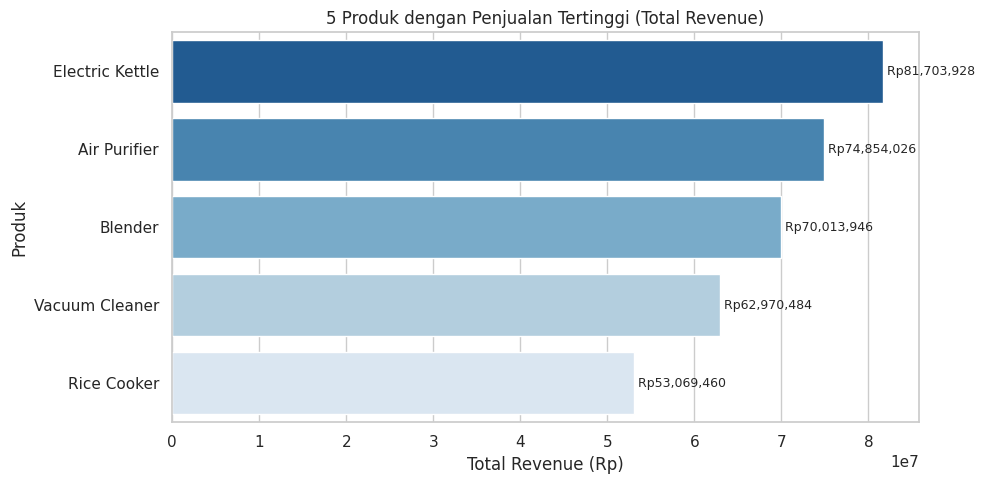

In [15]:
fig, ax = plt.subplots()
sns.barplot(data=top5_produk, x='total_revenue', y='product_name', palette='Blues_r', ax=ax)
ax.set_title('5 Produk dengan Penjualan Tertinggi (Total Revenue)')
ax.set_xlabel('Total Revenue (Rp)')
ax.set_ylabel('Produk')
for i, v in enumerate(top5_produk['total_revenue']):
    ax.text(v, i, f" Rp{v:,.0f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('output/chart1_top5_produk.png', dpi=150)
plt.show()


### Chart 2 — Total Quantity Terjual per Wilayah

/tmp/ipykernel_532/345114439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ringkasan_wilayah, x='region_name', y='total_quantity', palette='Greens_r', ax=ax)


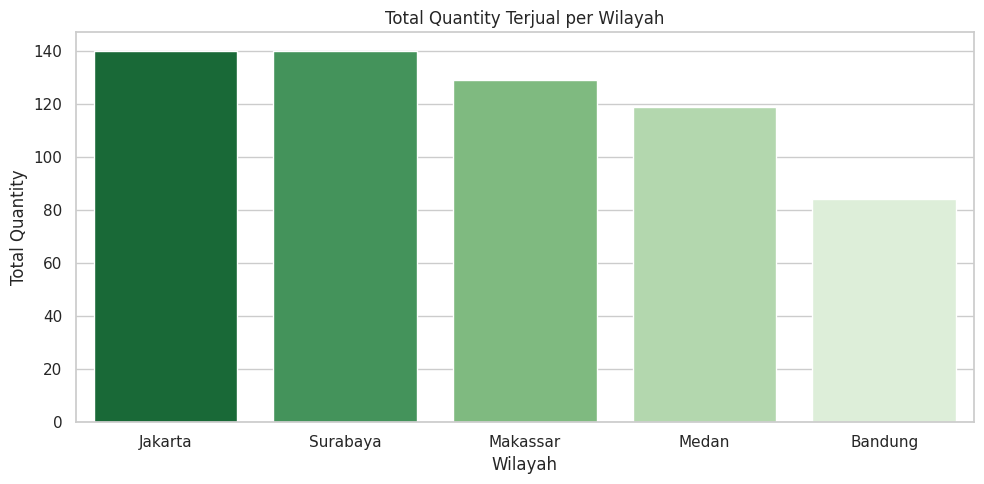

In [16]:
fig, ax = plt.subplots()
sns.barplot(data=ringkasan_wilayah, x='region_name', y='total_quantity', palette='Greens_r', ax=ax)
ax.set_title('Total Quantity Terjual per Wilayah')
ax.set_xlabel('Wilayah')
ax.set_ylabel('Total Quantity')
plt.tight_layout()
plt.savefig('output/chart2_wilayah.png', dpi=150)
plt.show()


### Chart 3 — Tren Penjualan Bulanan per Produk

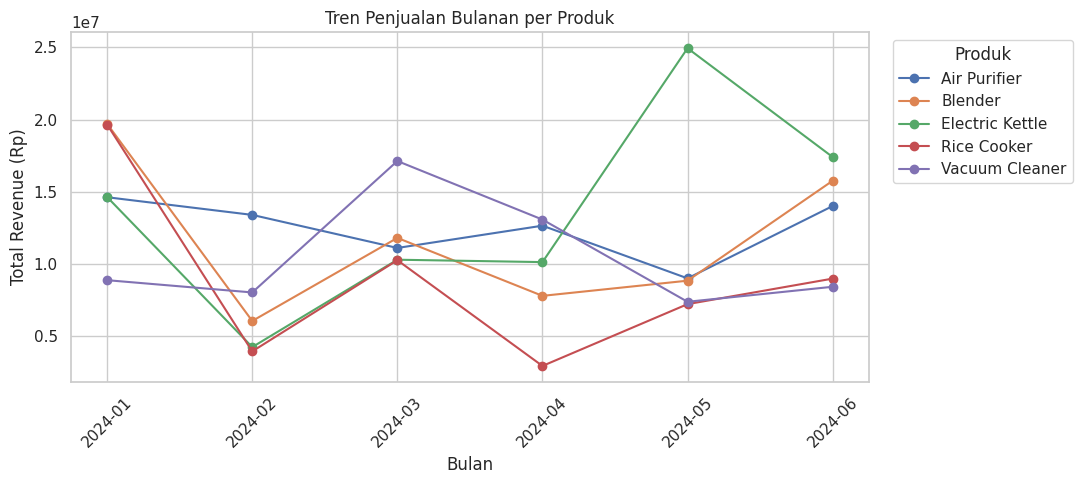

In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
for produk in penjualan_bulanan_produk_pivot.columns:
    ax.plot(penjualan_bulanan_produk_pivot.index, penjualan_bulanan_produk_pivot[produk], marker='o', label=produk)
ax.set_title('Tren Penjualan Bulanan per Produk')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Revenue (Rp)')
ax.legend(title='Produk', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('output/chart3_tren_bulanan.png', dpi=150)
plt.show()


### Chart 4 — Heatmap Revenue: Produk x Wilayah

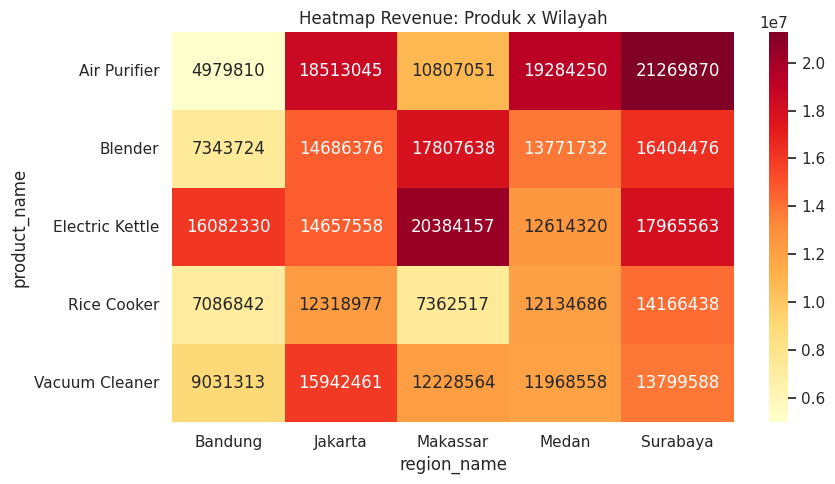

In [18]:
heatmap_data = df.pivot_table(index='product_name', columns='region_name', values='total_price', aggfunc='sum', fill_value=0)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax)
ax.set_title('Heatmap Revenue: Produk x Wilayah')
plt.tight_layout()
plt.savefig('output/chart4_heatmap.png', dpi=150)
plt.show()


### Chart 5 — Rata-rata Nilai Transaksi (AOV) per Wilayah

/tmp/ipykernel_532/1968373444.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aov_wilayah, x='region_name', y='avg_order_value', palette='Purples_r', ax=ax)


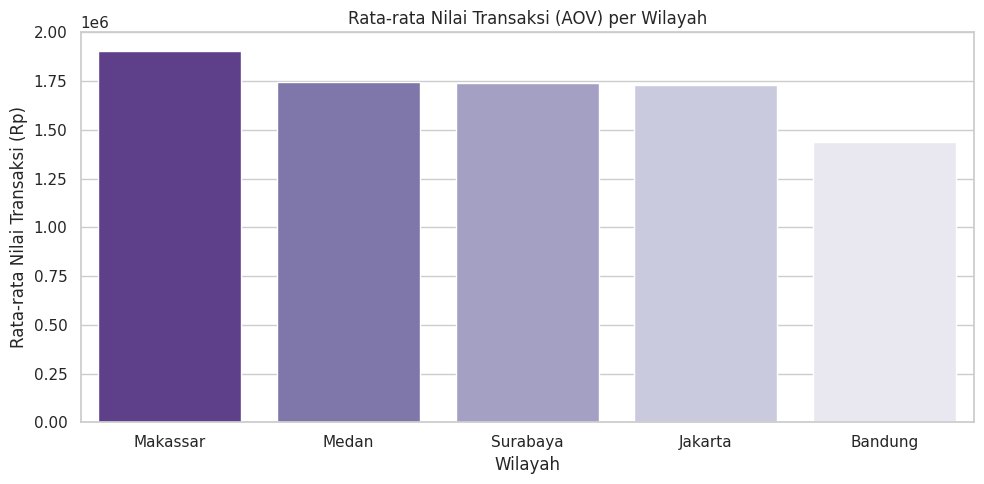

In [19]:
fig, ax = plt.subplots()
sns.barplot(data=aov_wilayah, x='region_name', y='avg_order_value', palette='Purples_r', ax=ax)
ax.set_title('Rata-rata Nilai Transaksi (AOV) per Wilayah')
ax.set_xlabel('Wilayah')
ax.set_ylabel('Rata-rata Nilai Transaksi (Rp)')
plt.tight_layout()
plt.savefig('output/chart5_aov_wilayah.png', dpi=150)
plt.show()


## 8. Kesimpulan Insight & Rekomendasi

**Insight Utama:**
1. **Produk terlaris** berdasarkan total revenue adalah kelompok 5 produk yang ditampilkan pada Chart 1 — produk-produk ini layak menjadi prioritas stok dan promosi.
2. **Wilayah dengan permintaan tertinggi** (quantity terjual terbanyak) terlihat pada Chart 2 — menunjukkan wilayah dengan basis pelanggan/potensi pasar terbesar saat ini.
3. **Tren bulanan** (Chart 3) menunjukkan pola naik-turun penjualan tiap produk sepanjang periode data, berguna untuk perencanaan stok musiman.
4. **Kombinasi produk x wilayah** (Chart 4 heatmap) mengungkap pasangan produk-wilayah dengan kontribusi revenue terbesar, sekaligus wilayah/produk yang masih kurang optimal.
5. **AOV per wilayah** (Chart 5) menunjukkan wilayah mana yang rata-rata nilai transaksinya tinggi meski volume transaksinya sedikit — berpotensi untuk strategi upsell/bundling, dibanding wilayah dengan transaksi banyak tapi nilai per transaksi kecil (cocok untuk strategi volume).

**Catatan Kualitas Data:**
Dataset awal mengandung baris duplikat, missing value pada `quantity`/`total_price`, format tanggal
tidak konsisten, dan beberapa `transaction_id` yang bentrok. Setelah proses cleaning (rekonsiliasi
`total_price = quantity x price_per_unit`, standardisasi tanggal, penghapusan duplikat penuh),
data menjadi layak dipakai untuk pengambilan keputusan.

**Rekomendasi Awal:**
- Fokuskan stok & campaign marketing pada 5 produk teratas, terutama di wilayah dengan kontribusi revenue tertinggi pada heatmap.
- Investigasi wilayah dengan quantity rendah — apakah karena kurangnya distribusi/promosi atau memang demand rendah.
- Manfaatkan pola tren bulanan untuk perencanaan inventori musiman agar tidak overstock/understock.
- Perbaiki proses input data di sumber (validasi format tanggal & ID transaksi) agar analisis berikutnya lebih efisien dan tidak butuh banyak cleaning manual.
